Testing with cleaning and transforming

In [ ]:
import pandas as pd

df1 = pd.read_csv("../data/landing/sms-call-internet-mi-2013-11-01.csv")

df1.head()

,datetime,CellID,countrycode,smsin,smsout,callin,callout,internet
0,2013-11-01 00:00:00,1,0,0.3521,NaN,NaN,0.0273,NaN
1,2013-11-01 00:00:00,1,33,NaN,NaN,NaN,NaN,0.0261
2,2013-11-01 00:00:00,1,39,1.7322,1.1047,0.5919,0.4020,57.7729
3,2013-11-01 00:00:00,2,0,0.3581,NaN,NaN,0.0273,NaN
4,2013-11-01 00:00:00,2,33,NaN,NaN,NaN,NaN,0.0274


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1891928 entries, 0 to 1891927
Data columns (total 8 columns):
 #   Column       Dtype  
---  ------       -----  
 0   datetime     object 
 1   CellID       int64  
 2   countrycode  int64  
 3   smsin        float64
 4   smsout       float64
 5   callin       float64
 6   callout      float64
 7   internet     float64
dtypes: float64(5), int64(2), object(1)
memory usage: 115.5+ MB


In [ ]:
# Convert datetime properly
df1['datetime'] = pd.to_datetime(df['datetime'])

# Replace NaN with 0
usage_cols = ['smsin', 'smsout', 'callin', 'callout', 'internet']
df1[usage_cols] = df[usage_cols].fillna(0)


In [ ]:
df1.info()
df1.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1891928 entries, 0 to 1891927
Data columns (total 8 columns):
 #   Column       Dtype         
---  ------       -----         
 0   datetime     datetime64[ns]
 1   CellID       int64         
 2   countrycode  int64         
 3   smsin        float64       
 4   smsout       float64       
 5   callin       float64       
 6   callout      float64       
 7   internet     float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 115.5 MB


datetime       0
CellID         0
countrycode    0
smsin          0
smsout         0
callin         0
callout        0
internet       0
dtype: int64

New Data SET with actual data exploration 

In [2]:
import pandas as pd
df = pd.read_csv("../data/landing/sms-call-internet-mi-2013-11-02.csv")
df.head()

,datetime,CellID,countrycode,smsin,smsout,callin,callout,internet
0,2013-11-02 00:00:00,1,0,0.2445,NaN,NaN,NaN,NaN
1,2013-11-02 00:00:00,1,39,1.4952,1.1213,0.2708,0.3004,46.5094
2,2013-11-02 00:00:00,1,53,0.0018,0.0036,NaN,NaN,NaN
3,2013-11-02 00:00:00,2,0,0.2458,NaN,NaN,NaN,NaN
4,2013-11-02 00:00:00,2,39,1.5028,1.1243,0.2751,0.3023,46.6933


In [3]:
# Head
print("\n-------------------Head of the data set-------------------\n")
print(df.head())

# Data types
print("\n-------------------datatypes of the data set------------------- \n")
print(df.dtypes)

# Summary statistics
print("\n-------------------Description of the data set------------------- \n")
print(df.describe())

# Null check
print("\n-------------------Null check of the data set------------------- \n")
print(df.isnull().sum())

missing_timestamps = df['datetime'].isnull().sum()
print("Missing timestamps:", missing_timestamps)

usage_cols = ['smsin', 'smsout', 'callin', 'callout', 'internet']

for col in usage_cols:
    negatives = (df[col] < 0).sum()
    print(f"Negative values in {col}: {negatives}")

duplicate_rows = df.duplicated().sum()
print("Duplicate rows:", duplicate_rows)


-------------------Head of the data set-------------------

              datetime  CellID  countrycode   smsin  smsout  callin  callout  \
0  2013-11-02 00:00:00       1            0  0.2445     NaN     NaN      NaN   
1  2013-11-02 00:00:00       1           39  1.4952  1.1213  0.2708   0.3004   
2  2013-11-02 00:00:00       1           53  0.0018  0.0036     NaN      NaN   
3  2013-11-02 00:00:00       2            0  0.2458     NaN     NaN      NaN   
4  2013-11-02 00:00:00       2           39  1.5028  1.1243  0.2751   0.3023   

   internet  
0       NaN  
1   46.5094  
2       NaN  
3       NaN  
4   46.6933  

-------------------datatypes of the data set------------------- 

datetime        object
CellID           int64
countrycode      int64
smsin          float64
smsout         float64
callin         float64
callout        float64
internet       float64
dtype: object

-------------------Description of the data set------------------- 

             CellID   countrycode       

Ploting of the current dataset after transforming and cleaning 

In [4]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day

df['total_usage'] = (
    df['smsin'] + df['smsout'] +
    df['callin'] + df['callout'] +
    df['internet']
)


Ploting of the dataset 

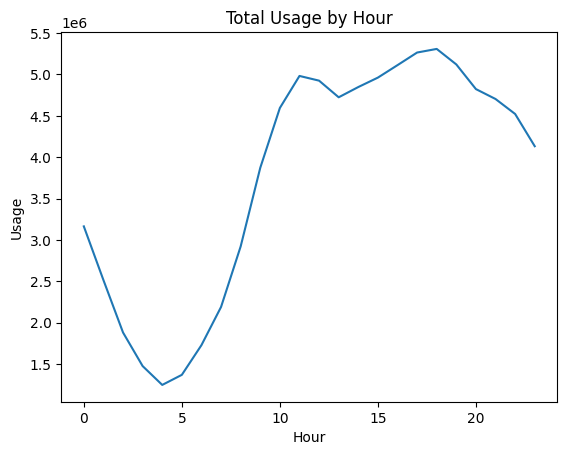

In [5]:
import matplotlib.pyplot as plt

usage_by_hour = df.groupby('hour')['total_usage'].sum()

usage_by_hour.plot()
plt.title("Total Usage by Hour")
plt.xlabel("Hour")
plt.ylabel("Usage")
plt.show()


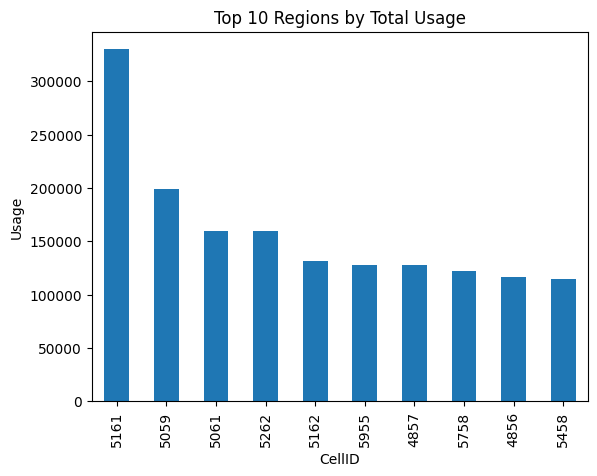

In [6]:
top_regions = df.groupby('CellID')['total_usage'].sum().nlargest(10)

top_regions.plot(kind='bar')
plt.title("Top 10 Regions by Total Usage")
plt.xlabel("CellID")
plt.ylabel("Usage")
plt.show()